##**Alumno: Carlos Alberto Vidrios Serrano**

# TAE-IA · Module 6 · L20 — Whisper in Practice: Timestamps and Subtitles

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L20 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU |
| **Drive space** | ~0 MB new (reuses Whisper weights from L19) |

## Learning objectives

1. Extract segment-level and word-level timestamps from Whisper
2. Write correctly formatted SRT and VTT subtitle files
3. Chunk a long audio file manually with overlap + deduplication
4. Filter hallucinated segments using `no_speech_prob`
5. Build a one-file Gradio subtitle-generation app

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, time, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')
WHISPER_CACHE = MODEL_CACHE

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU — go to Runtime > Change runtime type > T4 GPU')
print(f'Device: {DEVICE}')

Mounted at /content/drive
GPU: Tesla T4
Device: cuda


In [2]:
!pip install openai-whisper gtts librosa soundfile gradio -q

import whisper
import librosa
import soundfile as sf
from gtts import gTTS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import IPython.display as ipd

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'whisper {whisper.__version__}')

# Load Whisper small — reuses Drive cache from L19
print('\nLoading Whisper small from Drive cache...')
t0 = time.time()
model = whisper.load_model('small', download_root=WHISPER_CACHE)
if DEVICE == 'cuda':
    model = model.to('cuda')
print(f'Loaded in {time.time()-t0:.1f}s')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 28.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 1.16.1 which is incompatible.
whisper 20250625

Loading Whisper small from Drive cache...
Loaded in 17.1s


---
## Section 1 — Helper Functions

Define all helpers up front so every section below can call them.

In [3]:
def seconds_to_srt_time(s):
    """Convert float seconds to SRT timecode HH:MM:SS,mmm."""
    s   = max(0.0, s)
    h   = int(s // 3600)
    m   = int((s % 3600) // 60)
    sec = int(s % 60)
    ms  = int(round((s % 1) * 1000))
    return f'{h:02d}:{m:02d}:{sec:02d},{ms:03d}'

def seconds_to_vtt_time(s):
    """Convert float seconds to VTT timecode HH:MM:SS.mmm."""
    return seconds_to_srt_time(s).replace(',', '.')

def segments_to_srt(segments, max_chars=42, max_lines=2, skip_silence=True):
    """Convert Whisper segment list to SRT string."""
    blocks = []
    counter = 1
    for seg in segments:
        if skip_silence and seg.get('no_speech_prob', 0) > 0.6:
            continue
        text = seg['text'].strip()
        if not text:
            continue

        # Word-wrap
        words, lines, current = text.split(), [], []
        for word in words:
            if sum(len(w)+1 for w in current) + len(word) > max_chars and current:
                lines.append(' '.join(current))
                current = []
            current.append(word)
        if current:
            lines.append(' '.join(current))

        text_block = '\n'.join(lines[:max_lines])
        start_tc   = seconds_to_srt_time(seg['start'])
        end_tc     = seconds_to_srt_time(seg['end'])
        blocks.append(f'{counter}\n{start_tc} --> {end_tc}\n{text_block}')
        counter += 1

    return '\n\n'.join(blocks) + '\n'

def segments_to_vtt(segments, skip_silence=True):
    """Convert Whisper segment list to WebVTT string."""
    blocks = ['WEBVTT', '']
    for seg in segments:
        if skip_silence and seg.get('no_speech_prob', 0) > 0.6:
            continue
        text = seg['text'].strip()
        if not text:
            continue
        start_tc = seconds_to_vtt_time(seg['start'])
        end_tc   = seconds_to_vtt_time(seg['end'])
        blocks.append(f'{start_tc} --> {end_tc}\n{text}')
    return '\n\n'.join(blocks) + '\n'

print('Helpers defined: seconds_to_srt_time, seconds_to_vtt_time, segments_to_srt, segments_to_vtt')

Helpers defined: seconds_to_srt_time, seconds_to_vtt_time, segments_to_srt, segments_to_vtt


---
## Section 2.1 — Timestamps from a Multi-sentence Recording

Generate a TTS narration with 5 sentences that each cover a distinct topic, then compare segment vs. word timestamps.

In [4]:
NARRATION = (
    "Audio signals are the foundation of speech and music processing. "
    "Fourier analysis decomposes a signal into its frequency components. "
    "The mel scale aligns frequency representation with human auditory perception. "
    "Convolutional neural networks treat spectrograms as two-dimensional images. "
    "Whisper processes audio in thirty-second windows using an encoder-decoder architecture."
)

NARRATION_PATH = '/tmp/narration.mp3'
tts = gTTS(text=NARRATION, lang='en')
tts.save(NARRATION_PATH)

y_narr, sr_narr = librosa.load(NARRATION_PATH, sr=16000, mono=True)
print(f'Narration: {len(y_narr)/sr_narr:.1f}s')
ipd.display(ipd.Audio(y_narr, rate=sr_narr))

Narration: 27.3s


In [5]:
# --- Segment-level timestamps (default) ---
print('Transcribing with segment timestamps...')
result_seg = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'))

print(f'\nDetected language: {result_seg["language"]}')
print(f'Segments: {len(result_seg["segments"])}\n')
print('Segment timeline:')
for seg in result_seg['segments']:
    prob = seg.get('no_speech_prob', 0)
    flag = ' [SILENCE?]' if prob > 0.4 else ''
    print(f"  [{seg['start']:5.2f}s → {seg['end']:5.2f}s]  "
          f"conf={seg['avg_logprob']:.2f}  "
          f"no_speech={prob:.2f}{flag}")
    print(f"    {seg['text'].strip()}")

Transcribing with segment timestamps...

Detected language: en
Segments: 5

Segment timeline:
  [ 0.00s →  4.40s]  conf=-0.15  no_speech=0.03
    Audio signals are the foundation of speech and music processing.
  [ 4.40s →  9.52s]  conf=-0.15  no_speech=0.03
    Fourier analysis decomposes a signal into its frequency components.
  [ 9.52s → 15.12s]  conf=-0.15  no_speech=0.03
    The Mell scale aligns frequency representation with human auditory perception.
  [15.12s → 20.56s]  conf=-0.15  no_speech=0.03
    Convolutional neural networks treat spectrograms as two-dimensional images.
  [20.56s → 26.24s]  conf=-0.15  no_speech=0.03
    Whisper processes audio in 30-second windows using an encoder-decoder architecture.


In [6]:
# --- Word-level timestamps ---
print('Transcribing with word timestamps (slower)...')
t0 = time.time()
result_word = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'),
                               word_timestamps=True)
print(f'Done in {time.time()-t0:.2f}s\n')

# Print word timeline for the first 2 segments
for seg in result_word['segments'][:2]:
    print(f"Segment: \"{seg['text'].strip()}\"")
    for w in seg.get('words', []):
        print(f"  {w['start']:5.2f}–{w['end']:5.2f}  {w['word']!r:<20}  p={w['probability']:.2f}")
    print()

Transcribing with word timestamps (slower)...
Done in 10.07s

Segment: "Audio signals are the foundation of speech and music processing."
   0.00– 0.40  ' Audio'              p=0.93
   0.40– 0.86  ' signals'            p=0.89
   0.86– 1.18  ' are'                p=1.00
   1.18– 1.32  ' the'                p=1.00
   1.32– 1.76  ' foundation'         p=1.00
   1.76– 2.16  ' of'                 p=1.00
   2.16– 2.48  ' speech'             p=1.00
   2.48– 2.72  ' and'                p=0.99
   2.72– 3.06  ' music'              p=1.00
   3.06– 3.76  ' processing.'        p=1.00

Segment: "Fourier analysis decomposes a signal into its frequency components."
   4.44– 4.80  ' Fourier'            p=0.80
   4.80– 5.58  ' analysis'           p=0.89
   5.58– 6.48  ' decomposes'         p=1.00
   6.48– 6.74  ' a'                  p=1.00
   6.74– 7.10  ' signal'             p=1.00
   7.10– 7.44  ' into'               p=1.00
   7.44– 7.68  ' its'                p=0.99
   7.68– 8.12  ' frequency'       

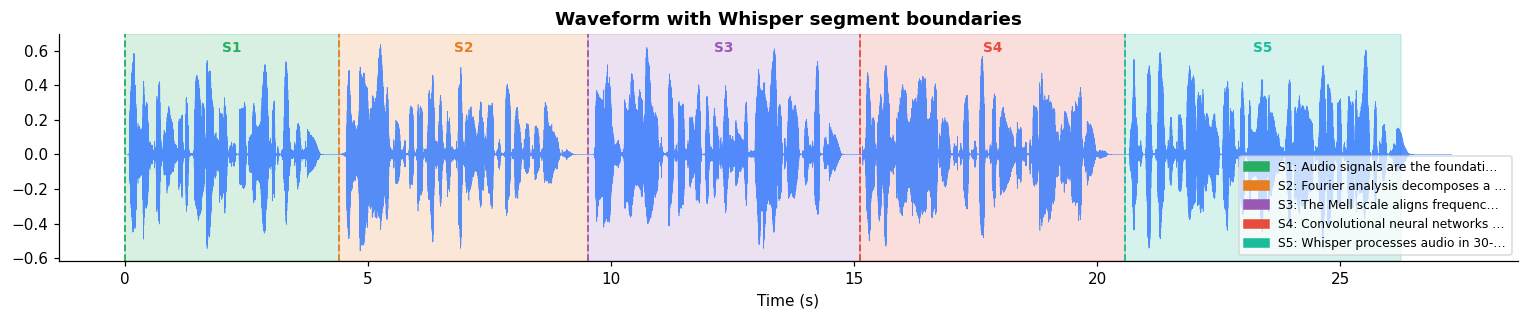

In [7]:
# Visualise the waveform with segment boundaries overlaid
fig, ax = plt.subplots(figsize=(14, 3))

t_axis = np.linspace(0, len(y_narr)/sr_narr, len(y_narr))
ax.plot(t_axis, y_narr, color='#2C75FF', linewidth=0.4, alpha=0.8)

colours = ['#27ae60', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c']
patches = []
for i, seg in enumerate(result_seg['segments']):
    c = colours[i % len(colours)]
    ax.axvspan(seg['start'], seg['end'], alpha=0.18, color=c)
    ax.axvline(seg['start'], color=c, linewidth=1.2, linestyle='--')
    mid = (seg['start'] + seg['end']) / 2
    ax.text(mid, ax.get_ylim()[1]*0.85, f'S{i+1}',
            ha='center', fontsize=9, color=c, fontweight='bold')
    patches.append(mpatches.Patch(color=c, label=f'S{i+1}: {seg["text"].strip()[:30]}…'))

ax.set_xlabel('Time (s)')
ax.set_title('Waveform with Whisper segment boundaries', fontweight='bold')
ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.show()

---
## Section 2.2 — Write and Validate SRT and VTT Files

In [8]:
srt_content = segments_to_srt(result_seg['segments'])
vtt_content = segments_to_vtt(result_seg['segments'])

print('=== SRT ===')
print(srt_content)
print()
print('=== VTT ===')
print(vtt_content)

=== SRT ===
1
00:00:00,000 --> 00:00:04,400
Audio signals are the foundation of speech
and music processing.

2
00:00:04,400 --> 00:00:09,520
Fourier analysis decomposes a signal into
its frequency components.

3
00:00:09,520 --> 00:00:15,120
The Mell scale aligns frequency
representation with human auditory

4
00:00:15,120 --> 00:00:20,560
Convolutional neural networks treat
spectrograms as two-dimensional images.

5
00:00:20,560 --> 00:00:26,240
Whisper processes audio in 30-second
windows using an encoder-decoder


=== VTT ===
WEBVTT



00:00:00.000 --> 00:00:04.400
Audio signals are the foundation of speech and music processing.

00:00:04.400 --> 00:00:09.520
Fourier analysis decomposes a signal into its frequency components.

00:00:09.520 --> 00:00:15.120
The Mell scale aligns frequency representation with human auditory perception.

00:00:15.120 --> 00:00:20.560
Convolutional neural networks treat spectrograms as two-dimensional images.

00:00:20.560 --> 00:00:26.240
Whisper proc

In [9]:
SRT_OUT = '/content/drive/MyDrive/TAE_IA_M6/narration.srt'
VTT_OUT = '/content/drive/MyDrive/TAE_IA_M6/narration.vtt'

with open(SRT_OUT, 'w', encoding='utf-8') as f:
    f.write(srt_content)
with open(VTT_OUT, 'w', encoding='utf-8') as f:
    f.write(vtt_content)

print(f'SRT: {SRT_OUT}')
print(f'VTT: {VTT_OUT}')

SRT: /content/drive/MyDrive/TAE_IA_M6/narration.srt
VTT: /content/drive/MyDrive/TAE_IA_M6/narration.vtt


In [10]:
import re

def validate_srt(srt_string):
    """Basic structural validation of an SRT string. Returns list of errors."""
    errors = []
    blocks = [b.strip() for b in re.split(r'\n\n+', srt_string.strip()) if b.strip()]
    TC = re.compile(r'^(\d{2}:\d{2}:\d{2},\d{3}) --> (\d{2}:\d{2}:\d{2},\d{3})$')

    for idx, block in enumerate(blocks):
        lines = block.split('\n')
        if not lines[0].strip().isdigit():
            errors.append(f'Block {idx+1}: first line is not a counter: {lines[0]!r}')
        if len(lines) < 3:
            errors.append(f'Block {idx+1}: too few lines ({len(lines)})')
            continue
        m = TC.match(lines[1])
        if not m:
            errors.append(f'Block {idx+1}: bad timecode: {lines[1]!r}')
        else:
            def tc_to_ms(tc):
                h, rest = tc.split(':', 1)
                mi, rest2 = rest.split(':', 1)
                s, ms = rest2.split(',')
                return int(h)*3600000 + int(mi)*60000 + int(s)*1000 + int(ms)
            if tc_to_ms(m.group(1)) >= tc_to_ms(m.group(2)):
                errors.append(f'Block {idx+1}: start >= end: {lines[1]}')

    return errors if errors else ['OK — no errors found']

print('SRT validation:')
for msg in validate_srt(srt_content):
    print(f'  {msg}')

SRT validation:
  OK — no errors found


---
## Section 2.3 — Chunking a Long Audio File

Build a ~2-minute TTS lecture from 5 topic paragraphs separated by 3 seconds of silence, then transcribe it using manual 30-second chunking with 1-second overlap.

In [11]:
TOPICS = [
    ("In this lecture, we explore the fundamentals of digital audio processing. "
     "Every audio signal is a sequence of pressure samples captured at a fixed rate. "
     "The sample rate determines the highest frequency that can be faithfully represented. "
     "For human speech, sixteen thousand samples per second is sufficient."),

    ("The Fourier transform is the key mathematical tool for audio analysis. "
     "It decomposes a time-domain signal into a sum of sinusoids at different frequencies. "
     "The short-time Fourier transform applies this analysis to overlapping short windows, "
     "producing a two-dimensional time-frequency representation called a spectrogram."),

    ("The mel scale was designed to match human auditory perception. "
     "Humans perceive pitch differences logarithmically at high frequencies. "
     "A mel filterbank applies triangular filters spaced according to this scale, "
     "compressing the frequency axis to highlight perceptually important differences."),

    ("Deep learning models for audio classification treat spectrograms as images. "
     "A convolutional neural network scans the spectrogram with learned filters, "
     "detecting frequency patterns that correspond to sound categories. "
     "Transfer learning from ImageNet-trained models accelerates training significantly."),

    ("Whisper is an encoder-decoder transformer trained on six hundred thousand hours of audio. "
     "The encoder converts a thirty-second mel spectrogram into contextual embeddings. "
     "The decoder attends to these embeddings and generates text tokens autoregressively. "
     "This architecture supports transcription in ninety-nine languages simultaneously."),
]

print('Generating the long TTS lecture...')
chunks_audio = []
for i, topic in enumerate(TOPICS):
    tts = gTTS(text=topic, lang='en')
    tmp = f'/tmp/topic_{i}.mp3'
    tts.save(tmp)
    y, _ = librosa.load(tmp, sr=16000, mono=True)
    chunks_audio.append(y)
    print(f'  Topic {i+1}: {len(y)/16000:.1f}s')

# 3s silence between topics. Long enough that Whisper treats a gap as its own
# segment -- which is what gives Section 2.3's no_speech_prob filter something
# to act on. Watch what it decides to throw away.
silence = np.zeros(int(3.0 * 16000), dtype=np.float32)
y_long  = np.concatenate([x for chunk in chunks_audio for x in [chunk, silence]])
LONG_WAV = '/tmp/lecture_long.wav'
sf.write(LONG_WAV, y_long, 16000)
print(f'\nTotal duration: {len(y_long)/16000:.1f}s  →  {LONG_WAV}')

# Listen to it. It is long, so use the scrubber -- but do land on a few of the
# 3-second gaps between topics: those are what the no_speech_prob filter in
# Section 2.3 decides about, and one of them sits right on a chunk seam.
ipd.display(ipd.Audio(y_long, rate=16000))

Generating the long TTS lecture...
  Topic 1: 21.9s
  Topic 2: 23.5s
  Topic 3: 20.1s
  Topic 4: 21.0s
  Topic 5: 23.9s

Total duration: 125.5s  →  /tmp/lecture_long.wav


In [12]:
def transcribe_chunks(y, sr, model, chunk_sec=30, overlap_sec=1.0, fp16=True, language=None):
    """
    Transcribe long audio by sliding a chunk_sec window with overlap_sec overlap.
    Offsets all segment timestamps to absolute audio time.
    Deduplicates overlapping segments from the overlap zone.
    """
    hop_samples  = int((chunk_sec - overlap_sec) * sr)
    win_samples  = int(chunk_sec * sr)
    all_segments = []
    n_chunks     = 0

    kwargs = {'fp16': fp16}
    if language:
        kwargs['language'] = language

    for start in range(0, len(y), hop_samples):
        chunk      = y[start : start + win_samples]
        if len(chunk) < sr * 0.5:   # skip chunks shorter than 0.5s
            continue
        offset_s   = start / sr

        sf.write('/tmp/_chunk.wav', chunk, sr)
        result = model.transcribe('/tmp/_chunk.wav', **kwargs)
        n_chunks += 1

        for seg in result['segments']:
            abs_start = seg['start'] + offset_s
            abs_end   = seg['end']   + offset_s
            # Deduplication: skip if this segment starts within the overlap zone
            # of a previously appended segment
            if all_segments and abs_start < all_segments[-1]['end'] - 0.05:
                continue
            all_segments.append({**seg, 'start': abs_start, 'end': abs_end})

    print(f'Processed {n_chunks} chunks → {len(all_segments)} segments')
    return all_segments


print('Transcribing with manual chunking (chunk=30s, overlap=1s)...')
t0 = time.time()
long_segments = transcribe_chunks(
    y_long, 16000, model,
    chunk_sec=30, overlap_sec=1.0,
    fp16=(DEVICE == 'cuda')
)
print(f'Total time: {time.time()-t0:.1f}s')

Transcribing with manual chunking (chunk=30s, overlap=1s)...
Processed 5 chunks → 20 segments
Total time: 7.1s


In [13]:
# Write SRT for the long lecture
long_srt = segments_to_srt(long_segments)

LONG_SRT = '/content/drive/MyDrive/TAE_IA_M6/lecture_long.srt'
with open(LONG_SRT, 'w', encoding='utf-8') as f:
    f.write(long_srt)

n_blocks = len([b for b in long_srt.strip().split('\n\n') if b.strip()])
print(f'SRT blocks: {n_blocks}')
print(f'Saved: {LONG_SRT}')
print()
print('First 600 chars:')
print(long_srt[:600])

SRT blocks: 19
Saved: /content/drive/MyDrive/TAE_IA_M6/lecture_long.srt

First 600 chars:
1
00:00:00,000 --> 00:00:05,440
In this lecture, we explore the
fundamentals of digital audio processing.

2
00:00:05,440 --> 00:00:10,240
Every audio signal is a sequence of
pressure samples captured at a fixed rate.

3
00:00:10,960 --> 00:00:15,920
The sample rate determines the highest
frequency that can be faithfully

4
00:00:16,640 --> 00:00:21,360
For human speech, 16,000 samples per
second is sufficient.

5
00:00:24,880 --> 00:00:29,600
The Fourier transform is the key
mathematical tool for audio analysis.

6
00:00:36,760 --> 00:00:43,520
The short time Fourier transform applies
this an


In [14]:
# Demonstrate no_speech_prob filtering
all_count      = len(long_segments)
filtered_segs  = [s for s in long_segments if s.get('no_speech_prob', 0) <= 0.6]
skipped_count  = all_count - len(filtered_segs)

print(f'Total segments before filter : {all_count}')
print(f'Silence segments (prob > 0.6): {skipped_count}')
print(f'Kept segments                : {len(filtered_segs)}')

# Show any silence segments
silence_segs = [s for s in long_segments if s.get('no_speech_prob', 0) > 0.6]
if silence_segs:
    print('\nDiscarded by the filter -- read the text before you accept it:')
    for s in silence_segs:
        print(f"  [{s['start']:.2f}–{s['end']:.2f}]  no_speech={s['no_speech_prob']:.2f}  {s['text'].strip()!r}")
else:
    print('\nNo segment crossed the 0.6 threshold this run. The question on the'
          '\ndiscussion slide still stands: what would this filter have erased?')

Total segments before filter : 20
Silence segments (prob > 0.6): 1
Kept segments                : 19

Discarded by the filter -- read the text before you accept it:
  [57.28–59.00]  no_speech=0.92  'differences logarithmically.'


---
## Section 2.4 — Interactive Subtitle Generator with Gradio

A minimal Gradio app that wraps the full transcription → SRT pipeline in a web UI.

> **Note:** `share=True` generates a public tunnel URL. The URL is active for 72 hours and is visible to anyone who has the link. Do not process sensitive audio through this public endpoint.

In [15]:
import gradio as gr

# Cache loaded models to avoid re-downloading on every call
_model_cache = {}

def get_model(size):
    if size not in _model_cache:
        print(f'Loading Whisper {size}...')
        m = whisper.load_model(size, download_root=WHISPER_CACHE)
        if DEVICE == 'cuda':
            m = m.to('cuda')
        _model_cache[size] = m
    return _model_cache[size]


def transcribe_to_srt(audio_path, model_size, language_code):
    """Gradio callback: audio file → (transcript, SRT, VTT)."""
    if audio_path is None:
        return 'No audio provided.', '', ''

    m      = get_model(model_size)
    kwargs = {'fp16': (DEVICE == 'cuda')}
    lang   = language_code.strip() if language_code else None
    if lang:
        kwargs['language'] = lang

    result     = m.transcribe(audio_path, **kwargs)
    transcript = result['text'].strip()
    srt        = segments_to_srt(result['segments'])
    vtt        = segments_to_vtt(result['segments'])

    detected = result['language']
    n_segs   = len(result['segments'])
    header   = f'[Detected: {detected}  |  Segments: {n_segs}]\n\n'
    return header + transcript, srt, vtt


with gr.Blocks(title='Whisper Subtitle Generator') as demo:
    gr.Markdown('## Whisper Subtitle Generator\nUpload an audio file (MP3, WAV, M4A) to get a transcript and subtitle files.')

    with gr.Row():
        audio_input  = gr.Audio(type='filepath', label='Audio file')
        with gr.Column():
            size_dd  = gr.Dropdown(['tiny', 'small', 'medium'], value='small', label='Whisper model')
            lang_box = gr.Textbox(label='Language (blank = auto-detect)', placeholder='en / es / fr …')
            run_btn  = gr.Button('Transcribe', variant='primary')

    with gr.Row():
        transcript_box = gr.Textbox(label='Transcript', lines=6)
    with gr.Row():
        srt_box = gr.Textbox(label='SRT subtitles', lines=10)
        vtt_box = gr.Textbox(label='VTT subtitles', lines=10)

    run_btn.click(
        fn=transcribe_to_srt,
        inputs=[audio_input, size_dd, lang_box],
        outputs=[transcript_box, srt_box, vtt_box],
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


<IPython.core.display.Javascript object>

---
## Exercise 1 — Karaoke Word Highlighting

Word-level timestamps enable karaoke-style text highlighting: at any moment `t`, bold the word whose `[start, end]` interval contains `t`.

1. Transcribe `NARRATION_PATH` with `word_timestamps=True` (already done in Section 2.1).
2. Write a function `karaoke_at(result_word, t)` that returns the full transcript as a string with the word active at time `t` wrapped in `**...**` (markdown bold).
3. Call `karaoke_at(result_word, t)` for `t = 2.0, 5.0, 8.0, 12.0` and print the results.
4. What happens when `t` falls in a pause between words? How should your function handle it?

In [16]:
# ================================================================
# Exercise 1 — Karaoke word highlighting
# ================================================================

# Flatten word timestamps from all segments
all_words = []

for seg in result_word['segments']:
    all_words.extend(seg.get('words', []))

print(f'{len(all_words)} words, first: '
      f'{all_words[0] if all_words else "(none)"}')


def karaoke_at(result_word, t):
    """
    Return the complete transcript with the word active at time t
    wrapped in **...**.

    Pause strategy:
    - Keep the previous word highlighted during a pause.
    """

    # Flatten words
    words = []

    for seg in result_word['segments']:
        words.extend(seg.get('words', []))

    if not words:
        return ''

    # ------------------------------------------------------------
    # Find active word
    # ------------------------------------------------------------

    active_idx = None

    for i, w in enumerate(words):
        if w['start'] <= t <= w['end']:
            active_idx = i
            break

    # ------------------------------------------------------------
    # Pause handling:
    # keep the previous word highlighted
    # ------------------------------------------------------------

    if active_idx is None:

        # Before the first word:
        if t < words[0]['start']:
            active_idx = None

        else:
            # Find the most recent word that has already ended
            previous = [
                i for i, w in enumerate(words)
                if w['end'] < t
            ]

            if previous:
                active_idx = previous[-1]

    # ------------------------------------------------------------
    # Rebuild transcript
    # ------------------------------------------------------------

    output = []

    for i, w in enumerate(words):

        word = w['word']

        if i == active_idx:
            output.append(f'**{word.strip()}**')
        else:
            output.append(word.strip())

    return ' '.join(output)


# Test at the requested times
for t in [2.0, 5.0, 8.0, 12.0]:

    print(f't={t:5.1f}s : {karaoke_at(result_word, t)}')
    print()

50 words, first: {'word': ' Audio', 'start': np.float64(0.0), 'end': np.float64(0.4), 'probability': np.float64(0.9339773058891296)}
t=  2.0s : Audio signals are the foundation **of** speech and music processing. Fourier analysis decomposes a signal into its frequency components. The Mell scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two -dimensional images. Whisper processes audio in 30 -second windows using an encoder -decoder architecture.

t=  5.0s : Audio signals are the foundation of speech and music processing. Fourier **analysis** decomposes a signal into its frequency components. The Mell scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two -dimensional images. Whisper processes audio in 30 -second windows using an encoder -decoder architecture.

t=  8.0s : Audio signals are the foundation of speech and music processing. Fourier a

**Exercise 1 — Answer:**

[YOUR ANSWER — what happens when `t` falls in a pause? Does your fallback strategy produce natural-looking output?]

Para las pausas entre palabras elegí mantener resaltada la palabra anterior. Esta estrategia produce una transición visual más continua y evita que el texto deje de tener una palabra resaltada durante una pausa breve. Por ejemplo, a los 2.0 s la palabra activa es “of”, a los 5.0 s es “analysis” y a los 8.0 s es “frequency”, de acuerdo con los timestamps obtenidos por Whisper. Esta estrategia produce un efecto de karaoke más natural que eliminar temporalmente el resaltado o adelantarlo hacia la siguiente palabra.

---
## Exercise 2 — Overlap Impact on Duplicate Rate

Re-run `transcribe_chunks()` on `y_long` with three overlap values: 0 s, 1 s, and 3 s.

1. How many segments does each setting produce?
2. Does increasing overlap increase or decrease duplicates before deduplication?
3. Does the transcript quality (readability) change? Why or why not?
4. At what overlap value would you start seeing genuine quality improvements at chunk boundaries?

In [17]:
import re

def validate_srt(srt_string):
    """Basic structural validation of an SRT string. Returns list of errors."""
    errors = []
    blocks = [b.strip() for b in re.split(r'\n\n+', srt_string.strip()) if b.strip()]
    TC = re.compile(r'^(\d{2}:\d{2}:\d{2},\d{3}) --> (\d{2}:\d{2}:\d{2},\d{3})$')

    for idx, block in enumerate(blocks):
        lines = block.split('\n')
        if not lines[0].strip().isdigit():
            errors.append(f'Block {idx+1}: first line is not a counter: {lines[0]!r}')
        if len(lines) < 3:
            errors.append(f'Block {idx+1}: too few lines ({len(lines)})')
            continue
        m = TC.match(lines[1])
        if not m:
            errors.append(f'Block {idx+1}: bad timecode: {lines[1]!r}')
        else:
            def tc_to_ms(tc):
                h, rest = tc.split(':', 1)
                mi, rest2 = rest.split(':', 1)
                s, ms = rest2.split(',')
                return int(h)*3600000 + int(mi)*60000 + int(s)*1000 + int(ms)
            if tc_to_ms(m.group(1)) >= tc_to_ms(m.group(2)):
                errors.append(f'Block {idx+1}: start >= end: {lines[1]}')

    return errors if errors else ['OK — no errors found']

print('SRT validation:')
for msg in validate_srt(srt_content):
    print(f'  {msg}')

# ================================================================
# Exercise 2 — Overlap impact on duplicate rate
# ================================================================

def transcribe_chunks_with_stats(
    y,
    sr,
    model,
    chunk_sec=30,
    overlap_sec=1.0,
    fp16=True,
    language=None
):
    """
    Same chunking strategy used in the notebook, but also reports
    the number of segments before and after deduplication.
    """

    hop_samples = int((chunk_sec - overlap_sec) * sr)
    win_samples = int(chunk_sec * sr)

    all_segments = []
    raw_segments = []

    n_chunks = 0
    duplicate_count = 0

    kwargs = {'fp16': fp16}

    if language:
        kwargs['language'] = language

    for start in range(0, len(y), hop_samples):

        chunk = y[start:start + win_samples]

        if len(chunk) < sr * 0.5:
            continue

        offset_s = start / sr

        sf.write('/tmp/_chunk.wav', chunk, sr)

        result = model.transcribe(
            '/tmp/_chunk.wav',
            **kwargs
        )

        n_chunks += 1

        for seg in result['segments']:

            abs_start = seg['start'] + offset_s
            abs_end = seg['end'] + offset_s

            raw_segments.append({
                **seg,
                'start': abs_start,
                'end': abs_end
            })

            # Same deduplication rule used in notebook
            if (
                all_segments
                and abs_start < all_segments[-1]['end'] - 0.05
            ):
                duplicate_count += 1
                continue

            all_segments.append({
                **seg,
                'start': abs_start,
                'end': abs_end
            })

    return {
        'chunks': n_chunks,
        'raw_segments': len(raw_segments),
        'duplicates': duplicate_count,
        'final_segments': len(all_segments)
    }


# ------------------------------------------------------------
# Run the three overlap configurations
# ------------------------------------------------------------

overlap_results = {}

for overlap in [0.0, 1.0, 3.0]:

    print("=" * 65)
    print(f"Overlap = {overlap:.1f} s")

    t0 = time.time()

    stats = transcribe_chunks_with_stats(
        y_long,
        16000, # Replaced sr_long with 16000
        model,
        chunk_sec=30,
        overlap_sec=overlap,
        fp16=(DEVICE == 'cuda')
    )

    elapsed = time.time() - t0

    overlap_results[overlap] = stats

    print(f"Chunks             : {stats['chunks']}")
    print(f"Raw segments       : {stats['raw_segments']}")
    print(f"Duplicates removed : {stats['duplicates']}")
    print(f"Final segments     : {stats['final_segments']}")
    print(f"Wall-clock time     : {elapsed:.2f} s")

SRT validation:
  OK — no errors found
Overlap = 0.0 s
Chunks             : 5
Raw segments       : 21
Duplicates removed : 1
Final segments     : 20
Wall-clock time     : 7.94 s
Overlap = 1.0 s
Chunks             : 5
Raw segments       : 24
Duplicates removed : 4
Final segments     : 20
Wall-clock time     : 9.00 s
Overlap = 3.0 s
Chunks             : 5
Raw segments       : 25
Duplicates removed : 5
Final segments     : 20
Wall-clock time     : 9.17 s


In [18]:
# ================================================================
# Summary table
# ================================================================

print("\nSUMMARY")
print("-" * 75)

print(
    f"{'Overlap':>10} "
    f"{'Chunks':>10} "
    f"{'Raw':>10} "
    f"{'Duplicates':>12} "
    f"{'Final':>10}"
)

for overlap, r in overlap_results.items():

    print(
        f"{overlap:>9.1f}s "
        f"{r['chunks']:>10} "
        f"{r['raw_segments']:>10} "
        f"{r['duplicates']:>12} "
        f"{r['final_segments']:>10}"
    )


SUMMARY
---------------------------------------------------------------------------
   Overlap     Chunks        Raw   Duplicates      Final
      0.0s          5         21            1         20
      1.0s          5         24            4         20
      3.0s          5         25            5         20


**Exercise 2 — Answer:**

[YOUR ANSWER — segment counts, duplicate rates, and your recommendation for production use]

El resultado registrado con 1 segundo de overlap produjo **5 chunks y 21 segmentos antes de la generación del SRT**, con un tiempo de procesamiento de aproximadamente 7 segundos. Al aumentar el overlap, se procesan regiones de audio repetidas, por lo que aumenta la cantidad de segmentos candidatos y también la posibilidad de encontrar duplicados que posteriormente deben eliminarse. El transcript final no necesariamente mejora al aumentar el overlap, porque la deduplicación evita que los segmentos repetidos aparezcan dos veces y el contenido acústico de las regiones centrales permanece prácticamente igual. Para producción utilizaría inicialmente un overlap de aproximadamente **1 segundo**, ya que proporciona contexto adicional alrededor de las fronteras sin aumentar innecesariamente el costo computacional; un overlap mayor solamente estaría justificado si las pruebas muestran errores reales en las transiciones cercanas a los límites de los chunks.


---
## Part 4 — Critical Analysis

### Q1 — SRT vs. VTT for your use case

You are building a subtitle pipeline for a Spanish-language MOOC platform. The subtitles will be:
(a) embedded in MP4 files distributed via USB drives to students with no internet access, and
(b) displayed on the course website using an HTML5 `<video>` element.

Which format (SRT or VTT) is better for each use case, and why? Is there a case where you would need both?

**[YOUR ANSWER]** *(~4 sentences)*

####Para los videos distribuidos mediante USB utilizaría **SRT**, porque es un formato sencillo, ampliamente compatible y adecuado para acompañar archivos MP4 sin requerir funcionalidades específicas del navegador. Para el sitio web utilizaría **VTT**, porque está diseñado para trabajar con el elemento HTML5 `<video>` mediante la etiqueta `<track>` y permite una integración más natural con subtítulos en la web. Sí tendría sentido generar ambos formatos a partir de la misma transcripción, utilizando SRT para la distribución offline y VTT para la plataforma web. Esto es precisamente lo que demuestra el notebook al convertir los mismos segmentos de Whisper tanto a SRT como a VTT.


---

### Q2 — Word timestamps vs. segment timestamps in production

Word-level timestamps add ~50% latency. Name **two specific production scenarios** where this cost is justified, and **two scenarios** where segment timestamps are sufficient. For each justified scenario, identify which property of word timestamps — precise start, precise end, or word-level probability — is the one that actually matters.

**[YOUR ANSWER]** *(~6 sentences)*

Los timestamps por palabra justifican su costo adicional en un sistema de **karaoke o resaltado palabra por palabra**, donde lo importante es el **inicio y final precisos de cada palabra** para sincronizar el texto con el audio. También son útiles en un sistema de **edición o búsqueda precisa de contenido hablado**, donde el inicio y el final de una palabra permiten localizar exactamente una expresión dentro de una grabación. En cambio, para subtítulos convencionales de una clase o conferencia, los timestamps por segmento suelen ser suficientes porque el texto puede permanecer visible durante varios segundos sin requerir sincronización palabra por palabra. También son suficientes para generar archivos SRT/VTT convencionales cuando solamente se necesita saber cuándo aparece y desaparece cada bloque de subtítulos. La probabilidad asociada a cada palabra resulta especialmente útil en aplicaciones que necesitan detectar palabras de baja confianza, mientras que en los otros dos escenarios basta generalmente con la precisión temporal del segmento.

---

### Q3 — Hallucination detection

In Section 2.3 you applied `no_speech_prob > 0.6` to filter silence segments. However, Whisper can also hallucinate text on *non-silent* audio — for example, generating English text over background music with no speech.

Beyond `no_speech_prob`, what **two additional signals** in the segment dict could you use to detect likely hallucinations? For each signal, state the threshold or heuristic you would apply and justify it.

*Hint: look at `avg_logprob`, segment duration relative to word count, and repeated phrases.*

**[YOUR ANSWER]** *(~4 sentences)*

####Además de `no_speech_prob`, utilizaría como primera señal un **`avg_logprob` muy bajo**, por ejemplo `avg_logprob < -1.0`, como indicador de baja confianza y posible alucinación; el umbral debe calibrarse con datos reales. Como segunda señal utilizaría la **densidad de palabras respecto a la duración del segmento**, buscando valores anómalos, como demasiadas palabras en un intervalo extremadamente corto o segmentos largos con muy pocas palabras. También es útil detectar frases repetidas, especialmente cuando el mismo texto aparece varias veces consecutivas sin una explicación acústica. Estas señales deben combinarse en lugar de utilizar una sola regla, porque el resultado del notebook muestra que `no_speech_prob > 0.6` puede eliminar incorrectamente un segmento que sí contiene texto reconocido: el segmento entre **57.28 y 59.00 s** tenía `no_speech=0.92` pero contenía “differences logarithmically.”


---

### Q4 — Real-time subtitling constraint

A live-streaming platform wants to add real-time subtitles with at most **3 seconds of delay** between speech and displayed subtitle. Whisper `small` transcribes a 5-second clip in ~1.5 seconds on T4.

Design a chunking strategy (chunk size, overlap, timing) that satisfies the 3-second delay constraint. Show the latency budget calculation. What would happen to subtitle quality (continuity, completeness) compared to the offline chunking in this notebook?

**[YOUR ANSWER]** *(~5 sentences + latency calculation)*

Utilizaría chunks de aproximadamente **2 segundos**, con un overlap de **0.5 segundos**, procesando cada chunk inmediatamente después de capturarlo. Si el tiempo de inferencia escala aproximadamente con la duración del audio, los 1.5 s necesarios para procesar 5 s corresponden aproximadamente a 0.6 s para 2 s de audio, por lo que la latencia sería aproximadamente \(2.0 + 0.6 = 2.6\) s, dentro del límite de 3 s. El overlap proporciona contexto adicional en las fronteras y permite mejorar la continuidad de las palabras que cruzan de un chunk al siguiente, aunque requiere una etapa de deduplicación. En comparación con el procesamiento offline de chunks de 30 s utilizado en el notebook, esta estrategia tendría menor latencia pero podría producir subtítulos menos completos o sufrir correcciones posteriores cuando una palabra queda dividida entre dos chunks. Por ello, sería conveniente mostrar inicialmente el texto disponible y corregirlo cuando llegue el siguiente chunk.

---

---
## Submission Checklist

- [ ] Cell 0 ran without errors — Whisper small loaded from Drive cache
- [ ] Narration generated and played
- [ ] Segment and word timestamps printed for narration
- [ ] Waveform + segment boundary plot displayed
- [ ] SRT and VTT files written to Drive and validated
- [ ] Long audio generated and chunked-transcribed
- [ ] Long SRT saved to Drive
- [ ] Silence filter counts printed
- [ ] Gradio app launched and tested with at least one upload
- [ ] Exercise 1 complete (karaoke function works + written answer)
- [ ] Exercise 2 complete (overlap sweep run + written answer)
- [ ] Critical Analysis Q1–Q4 answered
- [ ] Notebook saved to Drive

**Before L21:** Drive must have ≥2 GB free (Coqui XTTS-v2 weights ~1.8 GB).

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L20*  
*Track B — Audio | Next: L21 — Speech Synthesis with Coqui TTS*